# 02 · SGD vs APGD-SGD — Complex-Weight CVNN (v5)

Model: 1.24M complex params, stride-based downsampling.
Optimizer: v8 pure Armijo, eval() mode, Wirtinger gradients.


In [1]:
import os, sys, shutil

# ── Copy source files from dataset to /kaggle/working ─────────────────────────
# This ensures we always use the exact versions in the dataset,
# with no caching issues (copies happen fresh every kernel restart).
DATASET_DIR = "/kaggle/input/datasets/hardikgogia/apgd-2"

for fname in ["cvnn_model.py", "optimizers_v7.py"]:
    src = os.path.join(DATASET_DIR, fname)
    dst = os.path.join("/kaggle/working", fname)
    shutil.copy2(src, dst)
    print(f"Copied {fname}  ({os.path.getsize(dst):,} bytes)")

print("Done.")

Copied cvnn_model.py  (12,509 bytes)
Copied optimizers_v7.py  (17,074 bytes)
Done.


In [2]:
%matplotlib inline
import sys, os, itertools, copy, gc
sys.path.insert(0, '/kaggle/working')           # our files (cvnn_model, optimizers_v7)
sys.path.insert(1, '/kaggle/input/datasets/hardikgogia/apgd-2') # dataset files (merged_train.pt etc)

import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from torch.utils.data import DataLoader
import torch.nn as nn
from sklearn.metrics import (
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)

from cvnn_model      import CV_CNN
from optimizers_v7   import ComplexSGD, APGD_SGD
from dataset         import load_merged_dataset

torch.manual_seed(42)
np.random.seed(42)

# Sanity check: confirm we loaded the right files
m = CV_CNN(num_classes=10)
p = m.count_parameters()
print(f"Model: {p['complex_params']:,} complex params ({p['real_equivalent_params']:,} real-equiv)")
assert p['complex_params'] == 1_244_042, f"Wrong model loaded! Got {p['complex_params']}"
print("Model v5 confirmed.")
del m

Model: 1,244,042 complex params (2,488,084 real-equiv)
Model v5 confirmed.


In [3]:
# ── Constants ─────────────────────────────────────────────────────────────────
DATA_DIR   = "/kaggle/input/datasets/hardikgogia/apgd-2"
BATCH_SIZE = 64
EPOCHS     = 300
DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")

# ── Data loaders ──────────────────────────────────────────────────────────────
train_ds     = load_merged_dataset(os.path.join(DATA_DIR, "merged_train.pt"))
test_ds      = load_merged_dataset(os.path.join(DATA_DIR, "merged_test.pt"))
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=False)
val_loader   = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=False)
NUM_CLASSES  = train_ds.num_classes
print(f"Classes: {NUM_CLASSES}  |  Train: {len(train_ds)}  |  Val: {len(test_ds)}")

try:
    CLASS_NAMES = train_ds.class_names
except AttributeError:
    CLASS_NAMES = [str(i) for i in range(NUM_CLASSES)]
print(f"Classes: {CLASS_NAMES}")

torch.backends.cudnn.benchmark = True
CKPT_DIR = "/kaggle/working/checkpoints"
SAVE_DIR  = "/kaggle/working/plots/sgd"
os.makedirs(CKPT_DIR, exist_ok=True)
os.makedirs(SAVE_DIR,  exist_ok=True)
print(f"Checkpoint dir : {CKPT_DIR}")
print(f"Save dir       : {SAVE_DIR}")

Device : cuda
Classes: 10  |  Train: 6549  |  Val: 2596
Classes: ['bmp2_tank', 'btr70_transport', 't72_tank', 'd7_bulldozer', 't62_tank', 'zil131_truck', 'btr60_transport', 'zsu23-4_gun', 'brdm2_truck', '2s1_gun']
Checkpoint dir : /kaggle/working/checkpoints
Save dir       : /kaggle/working/plots/sgd


In [4]:
# ── APGD hyper-parameters (v8) ────────────────────────────────────────────────
STATIC_LR        = 0.03
SADDLE_BT_THRESH = 5
ALPHA_ARMIJO     = 0.3
BETA_BT          = 0.5
K_PHASES         = 17
MAX_BT           = 15
CLIP             = 2.0
print(f"APGD config: lr={STATIC_LR}  saddle_bt_thresh={SADDLE_BT_THRESH}  K={K_PHASES}  alpha={ALPHA_ARMIJO}")

APGD config: lr=0.03  saddle_bt_thresh=5  K=17  alpha=0.3


In [5]:
def train_static(model, loader, optimizer, criterion, clip=2.0):
    model.train()
    total = 0.0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(x), y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()
        total += loss.item()
    return total / len(loader)


def train_apgd(model, loader, optimizer_apgd, criterion):
    model.train()
    tot_loss, tot_theta, tot_gamma, n_saddle = 0.0, 0.0, 0.0, 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        loss, theta, gamma, regime = optimizer_apgd.step(x, y, criterion)
        tot_loss  += loss
        tot_theta += theta
        tot_gamma += gamma
        if regime == 'saddle':
            n_saddle += 1
    n = len(loader)
    return tot_loss/n, tot_theta/n, tot_gamma/n, n_saddle


@torch.no_grad()
def evaluate(model, loader, criterion):
    """Fast per-epoch evaluation — returns (loss, accuracy)."""
    model.eval()
    tot_loss, correct, total = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        out       = model(x)
        tot_loss += criterion(out, y).item()
        correct  += (out.argmax(1) == y).sum().item()
        total    += y.size(0)
    return tot_loss / len(loader), correct / total

In [6]:
# ── Full test evaluation ───────────────────────────────────────────────────────

@torch.no_grad()
def evaluate_full(model, loader, criterion, class_names=None):
    """
    Full evaluation pass.  Returns a dict with:
      loss, accuracy, per_class_acc, confusion matrix, preds, labels.
    """
    model.eval()
    tot_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        out       = model(x)
        tot_loss += criterion(out, y).item()
        preds     = out.argmax(1)
        correct  += (preds == y).sum().item()
        total    += y.size(0)
        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(y.cpu().tolist())

    n_classes = len(set(all_labels))
    names     = class_names or [str(i) for i in range(n_classes)]
    cm        = confusion_matrix(all_labels, all_preds, labels=list(range(n_classes)))
    per_class_acc = cm.diagonal() / cm.sum(axis=1).clip(min=1)

    return {
        'loss':          tot_loss / len(loader),
        'accuracy':      correct / total,
        'per_class_acc': per_class_acc,
        'cm':            cm,
        'preds':         all_preds,
        'labels':        all_labels,
        'class_names':   names,
    }


def print_test_report(results, title):
    """Prints overall accuracy, per-class bar table, and sklearn report."""
    names = results['class_names']
    print(f"\n{'═'*62}")
    print(f"  TEST REPORT — {title}")
    print(f"{'═'*62}")
    print(f"  Overall accuracy : {results['accuracy']*100:.2f}%")
    print(f"  Test loss        : {results['loss']:.4f}")
    print(f"\n  Per-class accuracy:")
    print(f"  {'Class':<20} {'Acc':>8}  {'N':>6}")
    print(f"  {'─'*40}")
    cm = results['cm']
    for i, (name, acc) in enumerate(zip(names, results['per_class_acc'])):
        n   = cm[i].sum()
        bar = '█' * int(acc * 20)
        print(f"  {name:<20} {acc*100:>7.2f}%  {n:>6d}  {bar}")
    print(f"\n  Classification report:")
    print(classification_report(
        results['labels'], results['preds'],
        target_names=names, digits=4))


def plot_confusion_matrix(results, title, save_dir, filename):
    """Side-by-side normalised and raw confusion matrices."""
    os.makedirs(save_dir, exist_ok=True)
    names = results['class_names']
    cm    = results['cm']
    cm_n  = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f"Confusion Matrix — {title}", fontsize=13, fontweight='bold')
    for ax, data, fmt, subtitle in zip(
            axes,
            [cm_n,    cm],
            ['.2f',   'd'],
            ['Normalised (row %)', 'Raw counts']):
        disp = ConfusionMatrixDisplay(confusion_matrix=data, display_labels=names)
        disp.plot(ax=ax, colorbar=True, cmap='Blues',
                  values_format=fmt, xticks_rotation=45)
        ax.set_title(subtitle, fontsize=11)
        ax.set_xlabel('Predicted', fontsize=9)
        ax.set_ylabel('True',      fontsize=9)
    plt.tight_layout()
    fname = os.path.join(save_dir, filename)
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close('all')  # ── memory: release figure after display ──────────────
    print(f"Saved → {fname}")


def plot_per_class_bar(results_static, results_apgd, save_dir):
    """Side-by-side per-class accuracy bar chart comparing both optimisers."""
    names = results_static['class_names']
    x     = np.arange(len(names))
    w     = 0.35

    fig, ax = plt.subplots(figsize=(14, 5))
    b1 = ax.bar(x - w/2, results_static['per_class_acc'] * 100,
                w, label='Static SGD θ=0', color='steelblue',  alpha=0.85)
    b2 = ax.bar(x + w/2, results_apgd['per_class_acc']   * 100,
                w, label='APGD-SGD',       color='darkorange', alpha=0.85)

    ax.axhline(results_static['accuracy'] * 100, color='steelblue',
               ls='--', lw=1.2, label=f"Static overall ({results_static['accuracy']*100:.1f}%)")
    ax.axhline(results_apgd['accuracy']   * 100, color='darkorange',
               ls='--', lw=1.2, label=f"APGD overall   ({results_apgd['accuracy']*100:.1f}%)")

    ax.set_xlabel('Class'); ax.set_ylabel('Accuracy (%)')
    ax.set_title('Per-Class Test Accuracy: Static SGD vs APGD-SGD')
    ax.set_xticks(x); ax.set_xticklabels(names, rotation=30, ha='right')
    ax.set_ylim(0, 108); ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)

    for bar in itertools.chain(b1, b2):
        h = bar.get_height()
        ax.annotate(f'{h:.1f}', xy=(bar.get_x() + bar.get_width()/2, h),
                    xytext=(0, 2), textcoords='offset points',
                    ha='center', va='bottom', fontsize=7)
    plt.tight_layout()
    fname = os.path.join(save_dir, 'SGD_per_class_acc.png')
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close('all')  # ── memory: release figure after display ──────────────
    print(f"Saved → {fname}")

In [7]:
# ── Training curve plots ───────────────────────────────────────────────────────

def plot_static_vs_apgd(static_hist, apgd_hist, title, save_dir):
    """
    5-panel figure:
      [0] Validation loss   [1] Train loss   [2] Validation accuracy
      [3] APGD: avg‖g‖ (raw) + saddle count per epoch
      [4] APGD: avg θ per epoch
    """
    os.makedirs(save_dir, exist_ok=True)
    ep  = range(1, len(static_hist['val_loss']) + 1)
    fig, axes = plt.subplots(1, 5, figsize=(25, 4))
    fig.suptitle(title, fontsize=13, fontweight='bold')

    # ── [0] Validation loss ──────────────────────────────────────────────────
    axes[0].plot(ep, static_hist['val_loss'], label='Static θ=0', lw=2, color='steelblue')
    axes[0].plot(ep, apgd_hist['val_loss'],   label='APGD',       lw=2, color='darkorange', ls='--')
    axes[0].set_title('Validation Loss'); axes[0].set_xlabel('Epoch')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    # ── [1] Train loss ───────────────────────────────────────────────────────
    axes[1].plot(ep, static_hist['train_loss'], label='Static θ=0', lw=2, color='steelblue')
    axes[1].plot(ep, apgd_hist['train_loss'],   label='APGD',       lw=2, color='darkorange', ls='--')
    axes[1].set_title('Train Loss'); axes[1].set_xlabel('Epoch')
    axes[1].legend(); axes[1].grid(True, alpha=0.3)

    # ── [2] Validation accuracy ──────────────────────────────────────────────
    axes[2].plot(ep, [a * 100 for a in static_hist['val_acc']],
                 label='Static θ=0', lw=2, color='steelblue')
    axes[2].plot(ep, [a * 100 for a in apgd_hist['val_acc']],
                 label='APGD',       lw=2, color='darkorange', ls='--')
    # Mark best val accuracy for each
    best_s_ep  = int(np.argmax(static_hist['val_acc'])) + 1
    best_s_acc = max(static_hist['val_acc']) * 100
    best_a_ep  = int(np.argmax(apgd_hist['val_acc'])) + 1
    best_a_acc = max(apgd_hist['val_acc']) * 100
    axes[2].scatter([best_s_ep], [best_s_acc], s=60, color='steelblue',  zorder=5)
    axes[2].scatter([best_a_ep], [best_a_acc], s=60, color='darkorange', zorder=5)
    axes[2].annotate(f'{best_s_acc:.1f}%', (best_s_ep, best_s_acc),
                     textcoords='offset points', xytext=(4, -10), fontsize=7, color='steelblue')
    axes[2].annotate(f'{best_a_acc:.1f}%', (best_a_ep, best_a_acc),
                     textcoords='offset points', xytext=(4,   4), fontsize=7, color='darkorange')
    axes[2].set_title('Validation Accuracy (%)'); axes[2].set_xlabel('Epoch')
    axes[2].set_ylim(0, 105); axes[2].legend(); axes[2].grid(True, alpha=0.3)
    axes[2].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))

    # ── [3] APGD: raw ‖g‖ (avg per epoch) + saddle count ────────────────────
    # gamma is now raw ‖g‖ (not ‖g‖/L̂) — label accordingly
    c_g, c_s = 'steelblue', 'crimson'
    ax3  = axes[3]
    ax3b = ax3.twinx()
    ax3.plot(ep, apgd_hist['gammas'],
             color=c_g, lw=1.5, label='avg ‖g‖ (raw)')
    ax3b.bar(ep, apgd_hist['saddle_counts'],
             color=c_s, alpha=0.35, width=1.0, label='saddle escapes / epoch')
    ax3.set_title('APGD: Gradient Norm & Saddle Escapes')
    ax3.set_xlabel('Epoch')
    ax3.set_ylabel('avg ‖g‖', color=c_g);         ax3.tick_params(axis='y', labelcolor=c_g)
    ax3b.set_ylabel('saddle escapes',  color=c_s); ax3b.tick_params(axis='y', labelcolor=c_s)
    lines  = ax3.get_legend_handles_labels()[0]  + ax3b.get_legend_handles_labels()[0]
    labels = ax3.get_legend_handles_labels()[1]  + ax3b.get_legend_handles_labels()[1]
    ax3.legend(lines, labels, fontsize=7); ax3.grid(True, alpha=0.3)

    # ── [4] APGD: avg selected θ per epoch ──────────────────────────────────
    ax4 = axes[4]
    ax4.plot(ep, np.degrees(apgd_hist['thetas']),
             color='purple', lw=1.5, label='avg θ* (°)')
    ax4.axhline(0, color='grey', ls='--', lw=0.8)
    ax4.fill_between(ep, np.degrees(apgd_hist['thetas']), 0,
                     alpha=0.12, color='purple')
    ax4.set_title('APGD: Avg Selected Phase θ*')
    ax4.set_xlabel('Epoch'); ax4.set_ylabel('θ* (degrees)')
    ax4.legend(fontsize=7); ax4.grid(True, alpha=0.3)

    plt.tight_layout()
    fname = os.path.join(save_dir, f"{title.replace(' ', '_')}_static_vs_apgd.png")
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close('all')  # ── memory: release figure after display ──────────────
    print(f"Saved → {fname}")


def summary_table(static_hist, apgd_hist, label):
    print(f"\n{'─'*64}")
    print(f"  {label}")
    print(f"{'─'*64}")
    print(f"  {'Strategy':<14} {'Best Val Loss':>14} {'Best Val Acc':>13} {'Final Acc':>10} {'@ Epoch':>9}")
    print(f"  {'─'*60}")
    for name, h in [('Static θ=0', static_hist), ('APGD-SGD', apgd_hist)]:
        ba   = max(h['val_acc'])
        bl   = min(h['val_loss'])
        fa   = h['val_acc'][-1]
        ep_b = h['val_acc'].index(ba) + 1
        print(f"  {name:<14} {bl:>14.4f} {ba:>12.4f} {fa:>10.4f} {ep_b:>9}")

In [8]:
SAVE_DIR  = "/kaggle/working/plots/sgd"
os.makedirs(SAVE_DIR, exist_ok=True)

model_s   = CV_CNN(num_classes=NUM_CLASSES).to(DEVICE)
opt_s     = ComplexSGD(model_s, lr=STATIC_LR, theta=0.0)
criterion = nn.CrossEntropyLoss()
hist_s    = {'train_loss': [], 'val_loss': [], 'val_acc': []}

# ── Capture initial state dict for matched initialization ──────────────────────
# Saved here so model_a can start from the exact same weights as model_s.
init_state_dict = copy.deepcopy(model_s.state_dict())

# ── Best-model tracking for Static SGD ────────────────────────────────────────
best_val_acc_s = 0.0

print(f"Static SGD  lr={STATIC_LR}  θ=0")
for epoch in range(1, EPOCHS + 1):
    tr     = train_static(model_s, train_loader, opt_s, criterion)
    vl, va = evaluate(model_s, val_loader, criterion)
    hist_s['train_loss'].append(tr)
    hist_s['val_loss'].append(vl)
    hist_s['val_acc'].append(va)
    if epoch % 10 == 0 or epoch == 1:
        print(f"  Ep {epoch:03d}  train={tr:.4f}  val={vl:.4f}  acc={va:.4f}")
    # ── Save best-model checkpoint ─────────────────────────────────────────────
    if va > best_val_acc_s:
        best_val_acc_s = va
        torch.save({
            'epoch':           epoch,
            'model_state_dict': model_s.state_dict(),
            'val_acc':         va,
            'val_loss':        vl,
            'train_loss':      tr,
            'hist':            hist_s,
        }, os.path.join(CKPT_DIR, "static_sgd_best.pt"))
    # ── Save periodic checkpoint every 50 epochs ───────────────────────────────
    if epoch % 50 == 0:
        torch.save({
            'epoch':           epoch,
            'model_state_dict': model_s.state_dict(),
            'hist':            hist_s,
        }, os.path.join(CKPT_DIR, f"static_sgd_ep{epoch:03d}.pt"))
print("Static SGD done.")

# ── Free GPU cache after run ───────────────────────────────────────────────────
torch.cuda.empty_cache()
gc.collect()

Static SGD  lr=0.03  θ=0
  Ep 001  train=2.2410  val=2.2801  acc=0.1067
  Ep 010  train=1.8209  val=2.0074  acc=0.2446
  Ep 020  train=1.5803  val=1.8127  acc=0.3582
  Ep 030  train=1.4783  val=1.5723  acc=0.4149
  Ep 040  train=1.4011  val=1.7377  acc=0.4052
  Ep 050  train=1.3403  val=1.4996  acc=0.4777
  Ep 060  train=1.2785  val=1.3572  acc=0.5200
  Ep 070  train=1.2038  val=1.4233  acc=0.5559
  Ep 080  train=1.1092  val=1.5162  acc=0.5077
  Ep 090  train=0.9964  val=1.4883  acc=0.5455
  Ep 100  train=0.9037  val=1.1881  acc=0.6221
  Ep 110  train=0.8076  val=0.8792  acc=0.6760
  Ep 120  train=0.7196  val=0.7872  acc=0.7327
  Ep 130  train=0.6401  val=0.9152  acc=0.7334
  Ep 140  train=0.5674  val=0.8319  acc=0.7639
  Ep 150  train=0.5134  val=0.6477  acc=0.7754
  Ep 160  train=0.4484  val=0.4859  acc=0.8451
  Ep 170  train=0.4056  val=0.7600  acc=0.7342
  Ep 180  train=0.3740  val=0.7457  acc=0.7565
  Ep 190  train=0.3535  val=0.3774  acc=0.8625
  Ep 200  train=0.3129  val=0.3293 

468


══════════════════════════════════════════════════════════════
  TEST REPORT — Static SGD (θ=0)
══════════════════════════════════════════════════════════════
  Overall accuracy : 85.25%
  Test loss        : 0.4694

  Per-class accuracy:
  Class                     Acc       N
  ────────────────────────────────────────
  bmp2_tank              58.43%     587  ███████████
  btr70_transport        87.76%     196  █████████████████
  t72_tank               89.19%     583  █████████████████
  d7_bulldozer           98.35%     121  ███████████████████
  t62_tank              100.00%     125  ████████████████████
  zil131_truck           98.26%     115  ███████████████████
  btr60_transport        79.12%      91  ███████████████
  zsu23-4_gun            96.03%     277  ███████████████████
  brdm2_truck            96.38%     276  ███████████████████
  2s1_gun                96.44%     225  ███████████████████

  Classification report:
                 precision    recall  f1-score   support


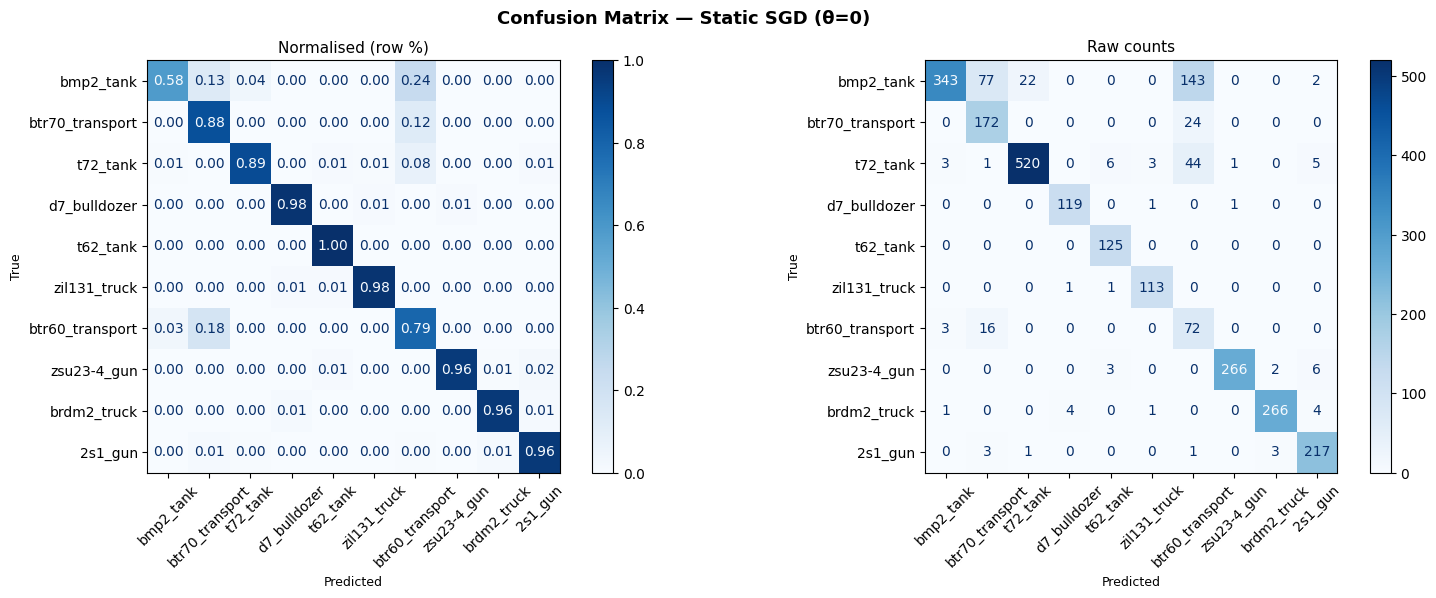

Saved → /kaggle/working/plots/sgd/SGD_static_confusion.png


In [9]:
# ── Static SGD — test evaluation ──────────────────────────────────────────────
results_static = evaluate_full(model_s, val_loader, criterion, CLASS_NAMES)
print_test_report(results_static, "Static SGD (θ=0)")
plot_confusion_matrix(results_static, "Static SGD (θ=0)",
                      SAVE_DIR, "SGD_static_confusion.png")

In [10]:
EPOCHS     = 300

model_a = CV_CNN(num_classes=NUM_CLASSES).to(DEVICE)

# ── Load same initialization as Static SGD for fair comparison ────────────────
# This ensures any accuracy gap is due to the optimizer, not initialization luck.
model_a.load_state_dict(copy.deepcopy(init_state_dict))

opt_a   = APGD_SGD(model_a,
                   base_lr         = STATIC_LR,
                   saddle_bt_thresh= SADDLE_BT_THRESH,
                   alpha           = ALPHA_ARMIJO,
                   beta            = BETA_BT,
                   K               = K_PHASES,
                   max_backtrack   = MAX_BT,
                   clip            = CLIP,
                   verbose         = 100)   # print every 100 batches (Kaggle output buffer)
hist_a  = {'train_loss': [], 'val_loss': [], 'val_acc': [],
           'thetas': [], 'gammas': [], 'saddle_counts': []}

# ── Best-model tracking for APGD-SGD ──────────────────────────────────────────
best_val_acc_a = 0.0

print(f"APGD-SGD  base_lr={STATIC_LR}  saddle_bt_thresh={SADDLE_BT_THRESH}  K={K_PHASES}")
for epoch in range(1, EPOCHS + 1):
    tr, avg_theta, avg_gamma, n_saddle = train_apgd(
        model_a, train_loader, opt_a, criterion)
    vl, va = evaluate(model_a, val_loader, criterion)
    hist_a['train_loss'].append(tr)
    hist_a['val_loss'].append(vl)
    hist_a['val_acc'].append(va)
    hist_a['thetas'].append(avg_theta)
    hist_a['gammas'].append(avg_gamma)
    hist_a['saddle_counts'].append(n_saddle)
    if epoch % 10 == 0 or epoch == 1:
        print(f"  Ep {epoch:03d}  train={tr:.4f}  val={vl:.4f}  acc={va:.4f}"
              f"  |  avg_θ={avg_theta:.3f}  avg_γ={avg_gamma:.3f}"
              f"  saddles={n_saddle}/{len(train_loader)}")
    # ── Save best-model checkpoint ─────────────────────────────────────────────
    if va > best_val_acc_a:
        best_val_acc_a = va
        torch.save({
            'epoch':           epoch,
            'model_state_dict': model_a.state_dict(),
            'val_acc':         va,
            'val_loss':        vl,
            'train_loss':      tr,
            'avg_theta':       avg_theta,
            'avg_gamma':       avg_gamma,
            'hist':            hist_a,
        }, os.path.join(CKPT_DIR, "apgd_sgd_best.pt"))
    # ── Save periodic checkpoint every 50 epochs ───────────────────────────────
    if epoch % 50 == 0:
        torch.save({
            'epoch':           epoch,
            'model_state_dict': model_a.state_dict(),
            'hist':            hist_a,
        }, os.path.join(CKPT_DIR, f"apgd_sgd_ep{epoch:03d}.pt"))
print("APGD-SGD done.")

# ── Free GPU cache after run ───────────────────────────────────────────────────
torch.cuda.empty_cache()
gc.collect()

APGD-SGD  base_lr=0.03  saddle_bt_thresh=5  K=17
  [APGD step   100]  loss=2.3276  g_raw=0.716  g_clip=0.716  bt0= 1  regime=normal  θ*=+0.000rad  rho=0.03000  bt1= 1
  Ep 001  train=2.2434  val=2.2545  acc=0.1186  |  avg_θ=-0.012  avg_γ=0.439  saddles=8/103
  [APGD step   200]  loss=2.0771  g_raw=0.681  g_clip=0.681  bt0= 1  regime=normal  θ*=+0.000rad  rho=0.03000  bt1= 1
  [APGD step   300]  loss=2.1876  g_raw=0.661  g_clip=0.661  bt0= 1  regime=normal  θ*=+0.000rad  rho=0.03000  bt1= 1
  [APGD step   400]  loss=2.1705  g_raw=0.588  g_clip=0.588  bt0= 1  regime=normal  θ*=+0.000rad  rho=0.03000  bt1= 1
  [APGD step   500]  loss=2.0305  g_raw=0.977  g_clip=0.977  bt0= 1  regime=normal  θ*=+0.000rad  rho=0.03000  bt1= 1
  [APGD step   600]  loss=2.1375  g_raw=0.892  g_clip=0.892  bt0= 1  regime=normal  θ*=+0.000rad  rho=0.03000  bt1= 1
  [APGD step   700]  loss=1.8919  g_raw=1.096  g_clip=1.096  bt0= 1  regime=normal  θ*=+0.000rad  rho=0.03000  bt1= 1
  [APGD step   800]  loss=1.9392 

22266


══════════════════════════════════════════════════════════════
  TEST REPORT — APGD-SGD
══════════════════════════════════════════════════════════════
  Overall accuracy : 91.49%
  Test loss        : 0.2525

  Per-class accuracy:
  Class                     Acc       N
  ────────────────────────────────────────
  bmp2_tank              91.31%     587  ██████████████████
  btr70_transport        76.53%     196  ███████████████
  t72_tank               92.97%     583  ██████████████████
  d7_bulldozer           95.04%     121  ███████████████████
  t62_tank               98.40%     125  ███████████████████
  zil131_truck           99.13%     115  ███████████████████
  btr60_transport        67.03%      91  █████████████
  zsu23-4_gun            98.56%     277  ███████████████████
  brdm2_truck            92.39%     276  ██████████████████
  2s1_gun                91.56%     225  ██████████████████

  Classification report:
                 precision    recall  f1-score   support

      

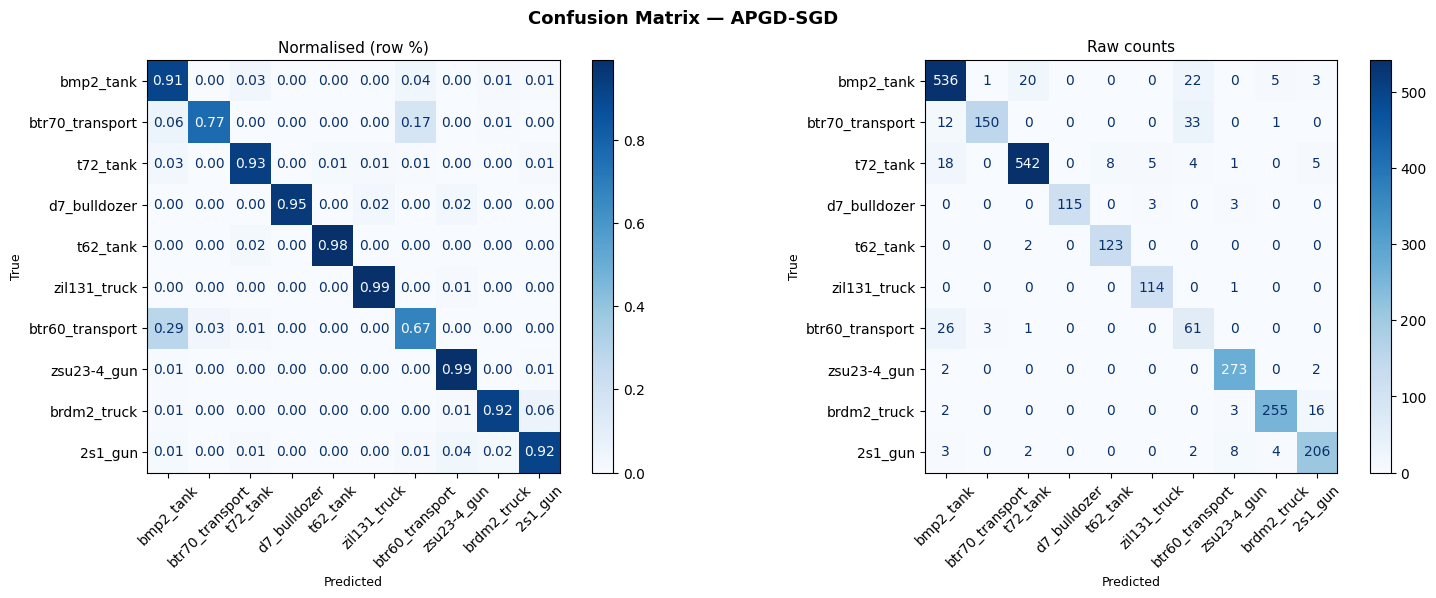

Saved → /kaggle/working/plots/sgd/SGD_apgd_confusion.png


In [11]:
# ── APGD-SGD — test evaluation ─────────────────────────────────────────────────
results_apgd = evaluate_full(model_a, val_loader, criterion, CLASS_NAMES)
print_test_report(results_apgd, "APGD-SGD")
plot_confusion_matrix(results_apgd, "APGD-SGD",
                      SAVE_DIR, "SGD_apgd_confusion.png")

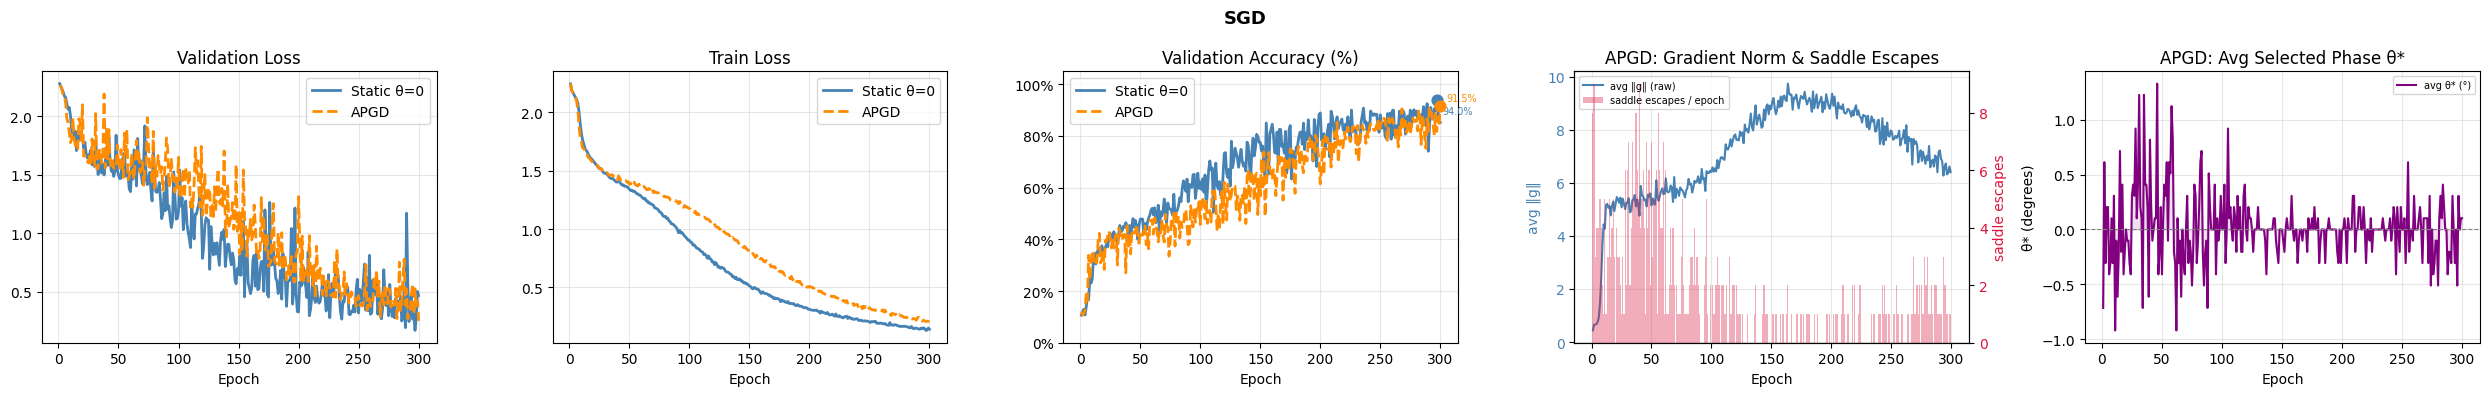

Saved → /kaggle/working/plots/sgd/SGD_static_vs_apgd.png

────────────────────────────────────────────────────────────────
  SGD
────────────────────────────────────────────────────────────────
  Strategy        Best Val Loss  Best Val Acc  Final Acc   @ Epoch
  ────────────────────────────────────────────────────────────
  Static θ=0             0.1713       0.9403     0.8525       297
  APGD-SGD               0.2525       0.9149     0.9149       300


In [12]:
plot_static_vs_apgd(hist_s, hist_a, "SGD", SAVE_DIR)
summary_table(hist_s, hist_a, "SGD")

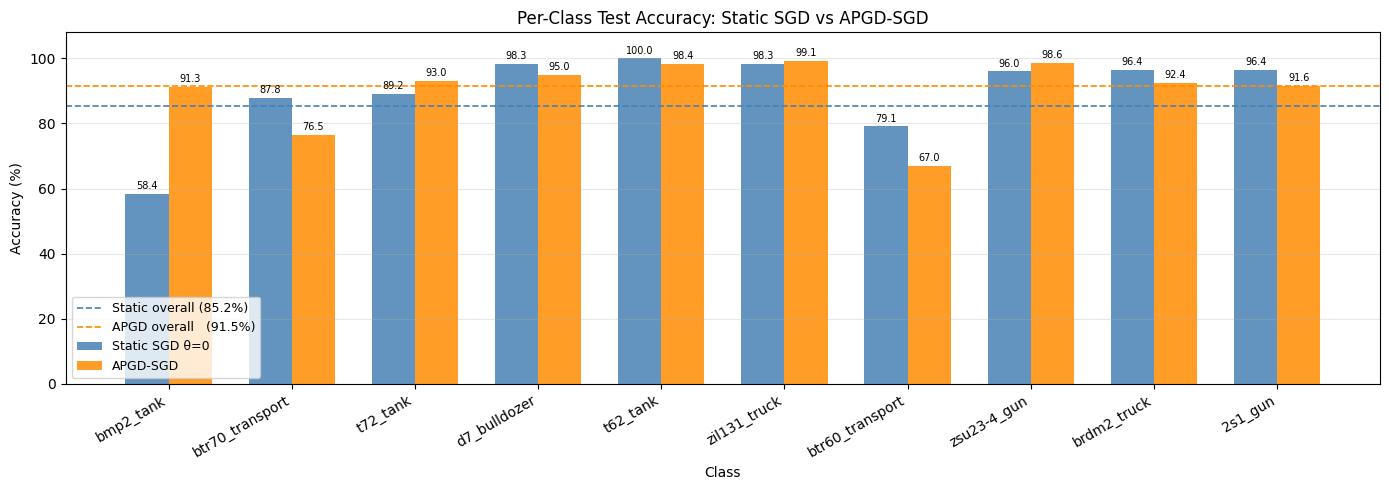

Saved → /kaggle/working/plots/sgd/SGD_per_class_acc.png

──────────────────────────────────────────────────────────
  Per-class Δ accuracy  (APGD − Static)
──────────────────────────────────────────────────────────
  Class                  Static      APGD         Δ
  ──────────────────────────────────────────────────────
  bmp2_tank              58.43%    91.31%   +32.88%  ▲
  btr70_transport        87.76%    76.53%   -11.22%  ▼
  t72_tank               89.19%    92.97%    +3.77%  ▲
  d7_bulldozer           98.35%    95.04%    -3.31%  ▼
  t62_tank              100.00%    98.40%    -1.60%  ▼
  zil131_truck           98.26%    99.13%    +0.87%  ▲
  btr60_transport        79.12%    67.03%   -12.09%  ▼
  zsu23-4_gun            96.03%    98.56%    +2.53%  ▲
  brdm2_truck            96.38%    92.39%    -3.99%  ▼
  2s1_gun                96.44%    91.56%    -4.89%  ▼


In [13]:
# ── Head-to-head per-class bar chart ───────────────────────────────────────────
plot_per_class_bar(results_static, results_apgd, SAVE_DIR)

# Delta table
print(f"\n{'─'*58}")
print(f"  Per-class Δ accuracy  (APGD − Static)")
print(f"{'─'*58}")
print(f"  {'Class':<20} {'Static':>8}  {'APGD':>8}  {'Δ':>8}")
print(f"  {'─'*54}")
for name, a_s, a_a in zip(
        CLASS_NAMES,
        results_static['per_class_acc'],
        results_apgd['per_class_acc']):
    delta = a_a - a_s
    arrow = '▲' if delta > 0.005 else ('▼' if delta < -0.005 else ' ')
    print(f"  {name:<20} {a_s*100:>7.2f}%  {a_a*100:>7.2f}%  {delta*100:>+7.2f}%  {arrow}")

In [14]:
# ── Save results for cross-optimizer comparison (notebook 05) ─────────────────
torch.save(
    {'static': hist_s, 'apgd': hist_a,
     'results_static': results_static, 'results_apgd': results_apgd},
    os.path.join(SAVE_DIR, "sgd_results.pt")
)
print(f"Results saved → {SAVE_DIR}/sgd_results.pt")

Results saved → /kaggle/working/plots/sgd/sgd_results.pt
